# India House Price Predictor — Model Development

## Project objective

Build a reproducible sale-price estimator for Indian residential listings. The notebook audits
the supplied Kaggle data, applies documented cleaning, compares three regression approaches,
selects a model without consulting the test set, evaluates the winner once, and exports a full
scikit-learn pipeline for FastAPI inference.

Raw listing text, identifiers, price-derived columns, and the dataset itself are excluded from
Git. Predictions are informational estimates, not valuations or investment advice.

## 1. Imports and reproducibility settings

In [1]:
from __future__ import annotations

import hashlib
import json
import platform
import random
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_validate, train_test_split

working_directory = Path.cwd()
if (working_directory / "backend").is_dir():
    project_root = working_directory
elif working_directory.name == "notebooks" and (working_directory.parent / "backend").is_dir():
    project_root = working_directory.parent
else:
    raise RuntimeError("Run from Final-Project or Final-Project/notebooks.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from backend.app.services.modeling import (
    build_candidates,
    learn_price_per_sqft_bounds,
    regression_scores,
    training_outlier_mask,
)
from backend.app.services.preprocessing import (
    CATEGORICAL_FEATURES,
    FEATURE_NAMES,
    NUMERIC_FEATURES,
    RANDOM_SEED,
    TARGET_COLUMN,
    clean_raw_listings,
)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

data_path = project_root / "notebooks" / "data" / "house_prices.csv"
models_directory = project_root / "models"
models_directory.mkdir(exist_ok=True)

if not data_path.is_file():
    raise FileNotFoundError(
        "Missing dataset: place 'house_prices.csv' in 'Final-Project/notebooks/data/'. "
        "See notebooks/data/README.md for Kaggle download instructions."
    )

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Random seed:", RANDOM_SEED)

Python: 3.11.9
pandas: 2.2.3
NumPy: 2.1.3
scikit-learn: 1.6.1
Random seed: 42


## 2. Load and inspect

The raw file is loaded only from the documented relative location. The notebook reports schema
and aggregate quality information without displaying listing titles, descriptions, or records.

In [2]:
raw = pd.read_csv(data_path, low_memory=False)

dataset_sha256 = hashlib.sha256()
with data_path.open("rb") as handle:
    for chunk in iter(lambda: handle.read(1024 * 1024), b""):
        dataset_sha256.update(chunk)
dataset_checksum = dataset_sha256.hexdigest().upper()

audit_table = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "missing": raw.isna().sum(),
        "missing_pct": raw.isna().mean().mul(100),
        "unique": raw.nunique(dropna=True),
    }
)

print("Raw shape:", raw.shape)
print("Deep memory (MiB):", round(raw.memory_usage(deep=True).sum() / 1024**2, 2))
print("SHA-256:", dataset_checksum)
print("Exact duplicates including Index:", int(raw.duplicated().sum()))
print(
    "Duplicate source records excluding Index:",
    int(raw.duplicated(subset=[column for column in raw.columns if column != "Index"]).sum()),
)
display(audit_table.round({"missing_pct": 4}))

Raw shape: (187531, 21)


Deep memory (MiB): 258.43
SHA-256: ED1E6A1A2D1158F458CEF164F7E977F2C32A1EE392AD218037C11851814EF1E3


Exact duplicates including Index: 0


Duplicate source records excluding Index: 119339


,dtype,missing,missing_pct,unique
Index,int64,0,0.0000,187531
Title,object,0,0.0000,32446
Description,object,3023,1.6120,65634
Amount(in rupees),object,0,0.0000,1561
Price (in rupees),float64,17665,9.4198,10958
location,object,0,0.0000,81
Carpet Area,object,80673,43.0185,2758
Status,object,615,0.3279,1
Floor,object,7077,3.7738,947
Transaction,object,83,0.0443,4


### Audit summary

- All 21 raw columns are listed above; only `Index` and `Price (in rupees)` are stored as numeric.
- `Dimensions` and `Plot Area` are completely empty; `Status` has one non-null value.
- `Society`, `Super Area`, and `Car Parking` are more than 50% missing.
- `Title`, `Description`, and `Society` are high-cardinality listing identifiers or text.
- `Amount(in rupees)` is the target source. `Price (in rupees)` is price-derived and would leak
  target information, so it is never used as a feature.

The complete factual audit and every dropped-column decision are in `docs/data-audit.md`.

## 3. Cleaning and feature engineering

In [3]:
cleaned, cleaning_counts = clean_raw_listings(raw)
X = cleaned[FEATURE_NAMES].copy()
y = cleaned[TARGET_COLUMN].copy()

print("Cleaning decisions:")
for decision, count in cleaning_counts.items():
    print(f"  {decision}: {count:,}")
print("Cleaned shape:", cleaned.shape)

cleaned_audit = pd.DataFrame(
    {
        "dtype": cleaned.dtypes.astype(str),
        "missing": cleaned.isna().sum(),
        "missing_pct": cleaned.isna().mean().mul(100),
        "unique": cleaned.nunique(dropna=True),
    }
)
display(cleaned_audit.round({"missing_pct": 3}))

Cleaning decisions:
  raw_rows: 187,531
  duplicate_source_rows: 119,339
  unusable_target_rows: 2,937
  missing_or_implausible_carpet_area_rows: 28,698
  grossly_implausible_price_area_rows: 5
  rental_rows: 1
  modeling_rows: 36,551
Cleaned shape: (36551, 12)


,dtype,missing,missing_pct,unique
carpet_area_sqft,float64,0,0.000,2473
floor_num,float64,499,1.365,51
total_floors,float64,507,1.387,70
bathroom,float64,15,0.041,11
balcony,float64,2495,6.826,11
parking,float64,17248,47.189,10
location,object,0,0.000,81
furnishing,object,23,0.063,3
transaction,object,60,0.164,3
ownership,object,6197,16.954,4


The target is Indian rupees parsed from `Amount(in rupees)`. Carpet areas are converted to square
feet; ambiguous regional units are rejected instead of guessed. Exact source duplicates are
removed before splitting. Deterministic integrity rules remove unavailable prices, missing or
grossly implausible carpet areas, rent listings, and only obvious price/area corruption outside
₹100-₹500,000 per sqft. Missing feature values remain for pipeline imputation.

No target-derived feature is created. Tighter price-per-square-foot outlier limits are learned
later from the training split only and are never learned from validation or test labels.

## 4. Exploratory data analysis

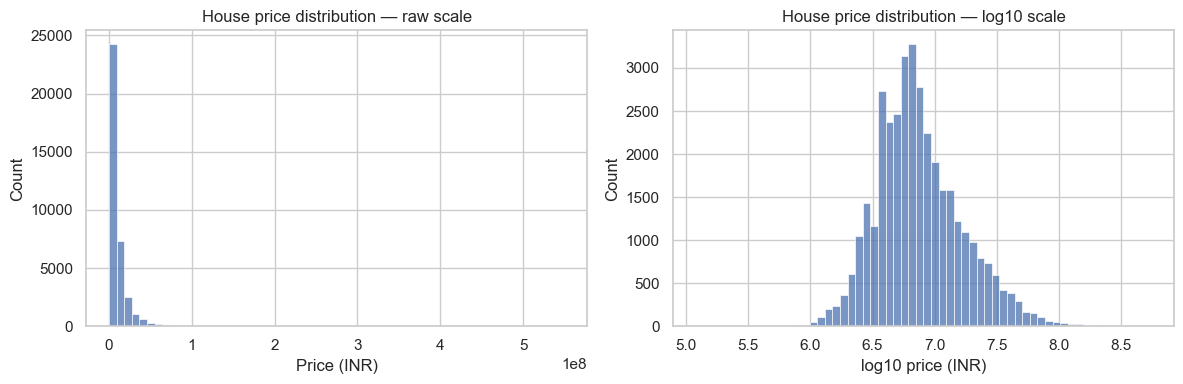

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(cleaned[TARGET_COLUMN], bins=60, ax=axes[0])
axes[0].set_title("House price distribution — raw scale")
axes[0].set_xlabel("Price (INR)")
sns.histplot(np.log10(cleaned[TARGET_COLUMN]), bins=60, ax=axes[1])
axes[1].set_title("House price distribution — log10 scale")
axes[1].set_xlabel("log10 price (INR)")
plt.tight_layout()
plt.show()

The raw target has a long right tail; the log view is more symmetric. This supports a log-target transformation for the non-linear candidate while retaining rupee-scale metrics.

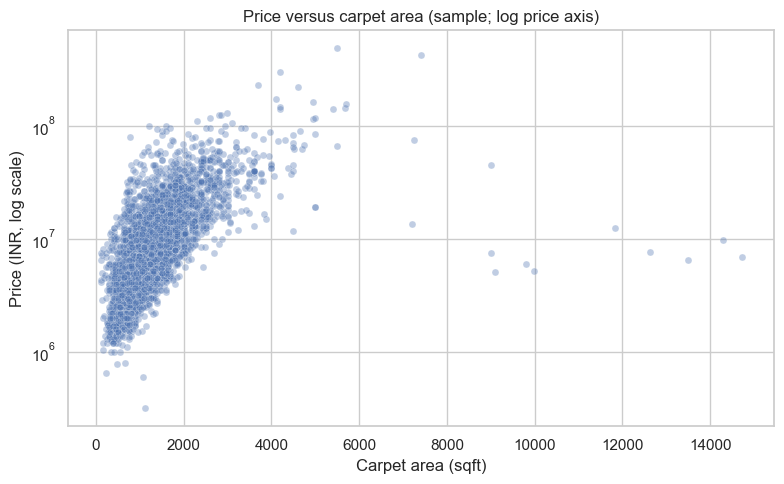

In [5]:
eda_sample = cleaned.sample(min(5_000, len(cleaned)), random_state=RANDOM_SEED)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=eda_sample,
    x="carpet_area_sqft",
    y=TARGET_COLUMN,
    alpha=0.35,
    s=25,
)
plt.yscale("log")
plt.title("Price versus carpet area (sample; log price axis)")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (INR, log scale)")
plt.tight_layout()
plt.show()

Larger carpet areas generally command higher prices, but location and property attributes create substantial spread at every area level.

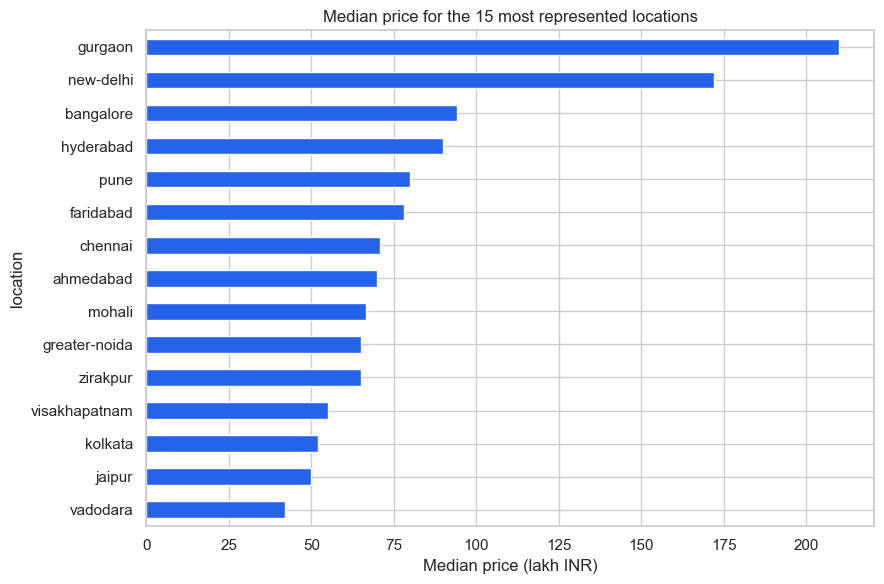

In [6]:
top_locations = cleaned["location"].value_counts().head(15).index
location_medians = (
    cleaned.loc[cleaned["location"].isin(top_locations)]
    .groupby("location", observed=True)[TARGET_COLUMN]
    .median()
    .sort_values()
)
plt.figure(figsize=(9, 6))
location_medians.div(100_000).plot(kind="barh", color="#2563eb")
plt.title("Median price for the 15 most represented locations")
plt.xlabel("Median price (lakh INR)")
plt.tight_layout()
plt.show()

Median prices differ markedly across well-represented locations, supporting location as a feature. Rare and unseen values will be grouped using training data only.

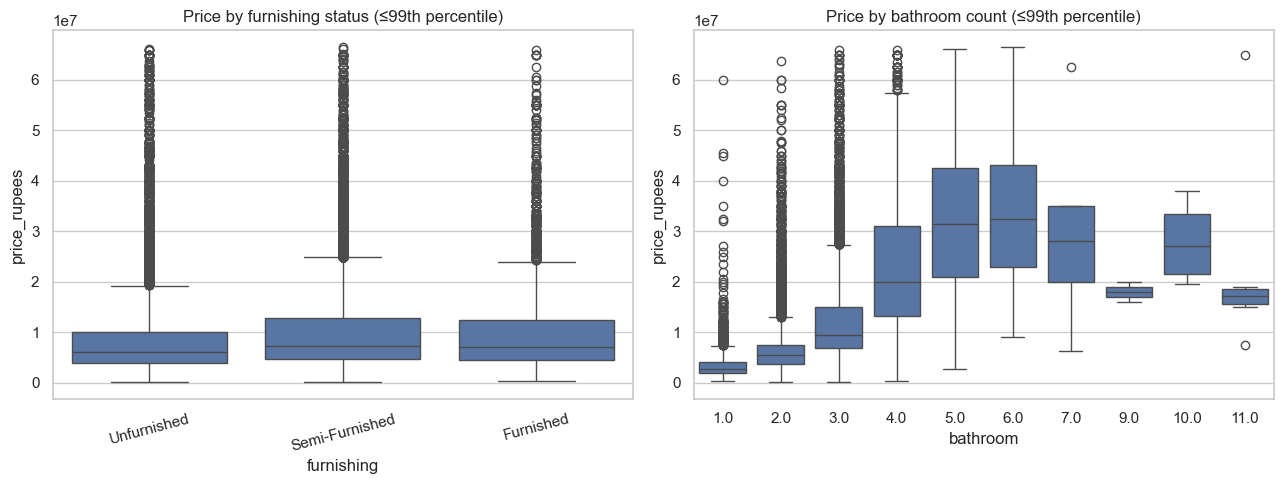

In [7]:
plot_data = cleaned.loc[cleaned[TARGET_COLUMN] <= cleaned[TARGET_COLUMN].quantile(0.99)].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=plot_data, x="furnishing", y=TARGET_COLUMN, ax=axes[0])
axes[0].set_title("Price by furnishing status (≤99th percentile)")
axes[0].tick_params(axis="x", rotation=15)
sns.boxplot(data=plot_data, x="bathroom", y=TARGET_COLUMN, ax=axes[1])
axes[1].set_title("Price by bathroom count (≤99th percentile)")
plt.tight_layout()
plt.show()

Furnishing groups overlap heavily, while additional bathrooms generally align with higher prices. Both remain useful conditional features rather than standalone valuation rules.

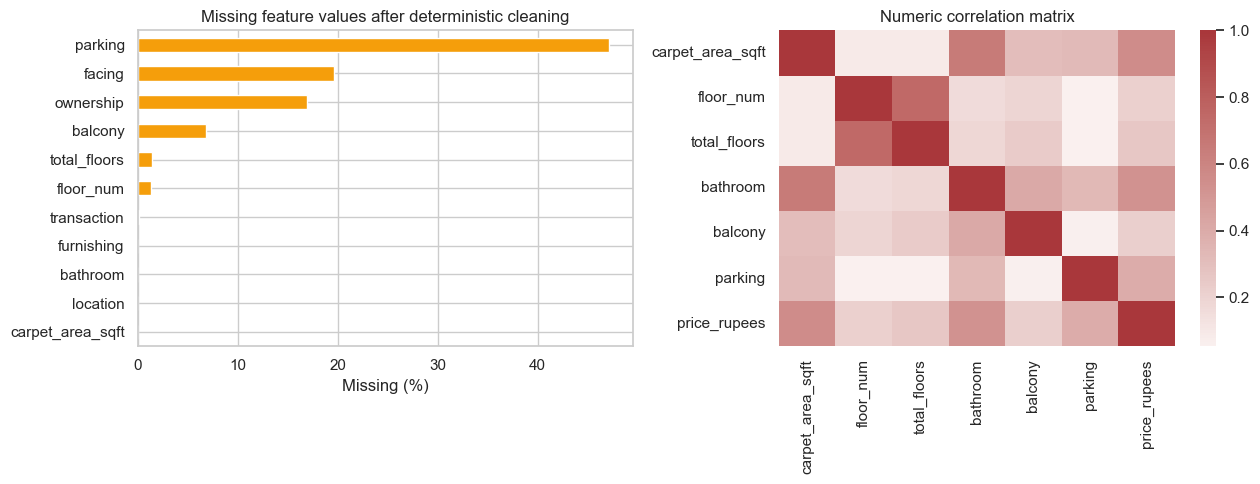

In [8]:
missing_percent = cleaned[FEATURE_NAMES].isna().mean().mul(100).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
missing_percent.plot(kind="barh", ax=axes[0], color="#f59e0b")
axes[0].set_title("Missing feature values after deterministic cleaning")
axes[0].set_xlabel("Missing (%)")

numeric_relationships = cleaned[[*NUMERIC_FEATURES, TARGET_COLUMN]].corr(numeric_only=True)
sns.heatmap(numeric_relationships, cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Numeric correlation matrix")
plt.tight_layout()
plt.show()

Parking has the greatest residual missingness and is imputed inside the pipeline. Area and bathroom count have the clearest positive numeric relationships with price, but no single feature explains the target.

## 5. Train, validation, and untouched test strategy

In [9]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_SEED
)

price_per_sqft_bounds = learn_price_per_sqft_bounds(X_train, y_train)
train_keep = training_outlier_mask(X_train, y_train, price_per_sqft_bounds)
X_train_filtered = X_train.loc[train_keep]
y_train_filtered = y_train.loc[train_keep]

print("Training rows before/after train-only outlier filter:", len(X_train), len(X_train_filtered))
print("Validation rows:", len(X_validation))
print("Untouched test rows:", len(X_test))
print("Train-learned price/sqft bounds:", tuple(round(value, 2) for value in price_per_sqft_bounds))

Training rows before/after train-only outlier filter: 21930 21490
Validation rows: 7310
Untouched test rows: 7311
Train-learned price/sqft bounds: (2234.21, 35495.52)


The 60% training, 20% validation, and 20% test partitions use seed 42. Candidate selection uses only filtered training rows and validation metrics. The test labels remain untouched until the winner and parameters are fixed. The 1st/99th percentile outlier bounds are learned only from training labels.

## 6. Baseline and candidate models

In [10]:
candidates = build_candidates()
validation_rows = []

for model_name, candidate in candidates.items():
    fit_started = time.perf_counter()
    candidate.fit(X_train_filtered, y_train_filtered)
    fit_seconds = time.perf_counter() - fit_started

    prediction_started = time.perf_counter()
    validation_predictions = candidate.predict(X_validation)
    prediction_seconds = time.perf_counter() - prediction_started

    validation_rows.append(
        {
            "model": model_name,
            **regression_scores(y_validation, validation_predictions),
            "fit_seconds": fit_seconds,
            "validation_prediction_seconds": prediction_seconds,
        }
    )

validation_results = pd.DataFrame(validation_rows).sort_values("mae_rupees").reset_index(drop=True)
validation_results["mae_lakh"] = validation_results["mae_rupees"] / 100_000
validation_results["rmse_lakh"] = validation_results["rmse_rupees"] / 100_000
display(validation_results.round(4))

,model,mae_rupees,rmse_rupees,r2,fit_seconds,validation_prediction_seconds,mae_lakh,rmse_lakh
0,Histogram gradient boosting log-target,3.061149e+06,9.989151e+06,0.6073,3.1074,0.1436,30.6115,99.8915
1,Ridge regression,4.270159e+06,1.178509e+07,0.4534,0.1150,0.0276,42.7016,117.8509
2,Dummy median,6.647547e+06,1.648393e+07,-0.0693,0.1141,0.0279,66.4755,164.8393


The dummy median establishes a no-skill reference, Ridge supplies a regularized linear comparison, and histogram gradient boosting models non-linear interactions while keeping training time and the serialized artifact practical. Selection is based on validation MAE; RMSE, R², fit time, and prediction time provide additional context.

## 7. Five-fold cross-validation

In [11]:
cv_sample_size = min(20_000, len(X_train_filtered))
cv_indices = X_train_filtered.sample(cv_sample_size, random_state=RANDOM_SEED).index
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_rows = []

for model_name, candidate in build_candidates().items():
    result = cross_validate(
        candidate,
        X_train_filtered.loc[cv_indices],
        y_train_filtered.loc[cv_indices],
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=1,
        error_score="raise",
    )
    cv_rows.append(
        {
            "model": model_name,
            "cv_rows": cv_sample_size,
            "cv_mae_mean_rupees": -result["test_mae"].mean(),
            "cv_mae_std_rupees": result["test_mae"].std(),
            "cv_rmse_mean_rupees": -result["test_rmse"].mean(),
            "cv_r2_mean": result["test_r2"].mean(),
            "cv_fit_seconds_mean": result["fit_time"].mean(),
        }
    )

cv_results = pd.DataFrame(cv_rows).sort_values("cv_mae_mean_rupees").reset_index(drop=True)
cv_results["cv_mae_mean_lakh"] = cv_results["cv_mae_mean_rupees"] / 100_000
cv_results["cv_rmse_mean_lakh"] = cv_results["cv_rmse_mean_rupees"] / 100_000
display(cv_results.round(4))

,model,cv_rows,cv_mae_mean_rupees,cv_mae_std_rupees,cv_rmse_mean_rupees,cv_r2_mean,cv_fit_seconds_mean,cv_mae_mean_lakh,cv_rmse_mean_lakh
0,Histogram gradient boosting log-target,20000,2.520994e+06,64412.2193,5.347087e+06,0.7782,2.4518,25.2099,53.4709
1,Ridge regression,20000,3.546915e+06,51146.0856,6.027687e+06,0.7163,0.0912,35.4692,60.2769
2,Dummy median,20000,5.927124e+06,154724.3672,1.185539e+07,-0.0966,0.0741,59.2712,118.5539


Five-fold CV is run on a fixed 20,000-row training-only sample to bound CPU and memory cost while still measuring stability. It is supporting evidence; validation MAE remains the predeclared selection criterion.

## 8. Final model selection and one-time test evaluation

In [12]:
selected_model_name = str(validation_results.iloc[0]["model"])
final_trainval_keep = training_outlier_mask(X_trainval, y_trainval, price_per_sqft_bounds)
final_model = clone(build_candidates()[selected_model_name])

final_fit_started = time.perf_counter()
final_model.fit(X_trainval.loc[final_trainval_keep], y_trainval.loc[final_trainval_keep])
final_fit_seconds = time.perf_counter() - final_fit_started

test_prediction_started = time.perf_counter()
test_predictions = final_model.predict(X_test)
test_prediction_seconds = time.perf_counter() - test_prediction_started
if not np.isfinite(test_predictions).all():
    raise RuntimeError("The selected model produced a non-finite test prediction.")

test_scores = regression_scores(y_test, test_predictions)
test_scores["mae_lakh"] = test_scores["mae_rupees"] / 100_000
test_scores["rmse_lakh"] = test_scores["rmse_rupees"] / 100_000

print("Selected model:", selected_model_name)
print(
    "Final train+validation rows after fixed training-learned filter:",
    int(final_trainval_keep.sum()),
)
print("Final fit seconds:", round(final_fit_seconds, 4))
print("Test prediction seconds:", round(test_prediction_seconds, 4))
display(pd.DataFrame([test_scores]).round(4))

Selected model: Histogram gradient boosting log-target
Final train+validation rows after fixed training-learned filter: 28649
Final fit seconds: 3.4346
Test prediction seconds: 0.1729


,mae_rupees,rmse_rupees,r2,mae_lakh,rmse_lakh
0,3.102653e+06,1.092492e+07,0.6045,31.0265,109.2492


The selected model is the validation-MAE winner. It is refit on training plus validation rows using the already-fixed training-derived outlier limits, then evaluated exactly once on the untouched test set. All reported MAE and RMSE values are original-scale rupees (and lakhs for readability), never training metrics.

## 9. Error and residual analysis

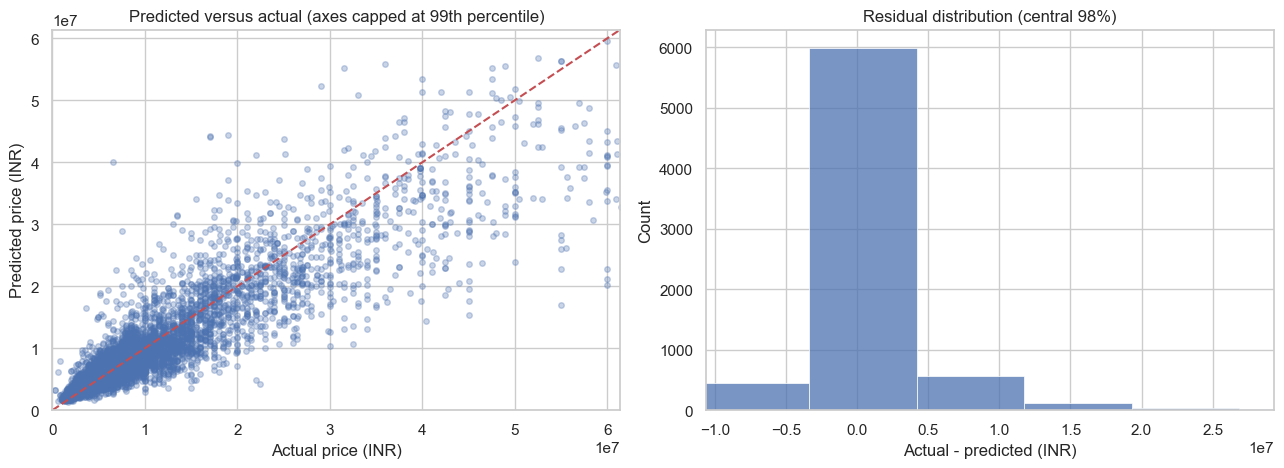

,absolute_error_rupees
count,7.311000e+03
mean,3.102653e+06
std,1.047580e+07
min,1.904600e+02
50%,1.220786e+06
75%,2.791335e+06
90%,6.319956e+06
95%,1.036569e+07
99%,3.006718e+07
max,4.117133e+08


In [13]:
residuals = y_test.to_numpy() - test_predictions
plot_limit = float(np.quantile(np.concatenate([y_test.to_numpy(), test_predictions]), 0.99))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, test_predictions, alpha=0.3, s=16)
axes[0].plot([0, plot_limit], [0, plot_limit], "r--", linewidth=1.5)
axes[0].set_xlim(0, plot_limit)
axes[0].set_ylim(0, plot_limit)
axes[0].set_title("Predicted versus actual (axes capped at 99th percentile)")
axes[0].set_xlabel("Actual price (INR)")
axes[0].set_ylabel("Predicted price (INR)")

sns.histplot(residuals, bins=60, ax=axes[1])
axes[1].set_xlim(np.quantile(residuals, 0.01), np.quantile(residuals, 0.99))
axes[1].set_title("Residual distribution (central 98%)")
axes[1].set_xlabel("Actual - predicted (INR)")
plt.tight_layout()
plt.show()

absolute_errors = np.abs(residuals)
error_summary = pd.Series(absolute_errors).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
display(error_summary.to_frame("absolute_error_rupees").round(2))

Errors widen for expensive properties, reflecting target skew, sparse luxury examples, and missing property details. The model is a portfolio demonstration and informational estimate, not a professional appraisal or production-grade valuation system.

## 10. Feature importance

,feature,mae_increase_rupees,std_rupees
0,carpet_area_sqft,3695148.35,85746.69
1,location,2320129.20,78799.02
2,bathroom,648258.25,48327.69
3,total_floors,521868.49,46385.42
4,parking,253877.40,13478.94
5,balcony,74322.13,13911.66
6,ownership,41772.97,3864.02
7,transaction,34737.62,6211.92
8,furnishing,31198.71,4641.72
9,facing,24616.27,4424.64


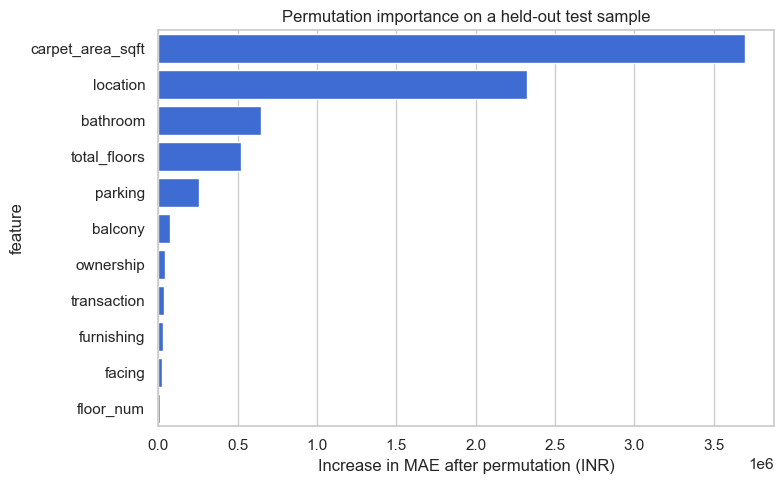

In [14]:
importance_indices = X_test.sample(min(2_000, len(X_test)), random_state=RANDOM_SEED).index
importance_result = permutation_importance(
    final_model,
    X_test.loc[importance_indices],
    y_test.loc[importance_indices],
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_SEED,
    n_jobs=1,
)
importance_table = (
    pd.DataFrame(
        {
            "feature": FEATURE_NAMES,
            "mae_increase_rupees": importance_result.importances_mean,
            "std_rupees": importance_result.importances_std,
        }
    )
    .sort_values("mae_increase_rupees", ascending=False)
    .reset_index(drop=True)
)
display(importance_table.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_table, x="mae_increase_rupees", y="feature", color="#2563eb")
plt.title("Permutation importance on a held-out test sample")
plt.xlabel("Increase in MAE after permutation (INR)")
plt.tight_layout()
plt.show()

Permutation importance measures predictive sensitivity, not causation. It is computed after the one-time evaluation and is not used to retune or select the model.

## 11. Export and reload sanity check

In [15]:
model_path = models_directory / "house_price.pkl"
locations_path = models_directory / "locations.json"
metadata_path = models_directory / "model_metadata.json"

joblib.dump(final_model, model_path, compress=3)

location_pipeline = final_model.named_steps["preprocessor"].named_transformers_["location"]
frequent_locations = location_pipeline.named_steps["rare"].frequent_categories_
allowed_locations = sorted(set(frequent_locations) | {"Other"})
locations_path.write_text(json.dumps(allowed_locations, indent=2), encoding="utf-8")

regressor_parameters = final_model.named_steps["regressor"].get_params(deep=True)
serializable_parameters = {
    key: value if isinstance(value, (str, int, float, bool, type(None))) else str(value)
    for key, value in regressor_parameters.items()
}

winner_cv = cv_results.loc[cv_results["model"].eq(selected_model_name)].iloc[0]
model_version = datetime.now(timezone.utc).strftime("%Y.%m.%d-%H%M%SZ")
input_schema = {
    "carpet_area_sqft": {"type": "number", "minimum": 100, "maximum": 20000},
    "floor_num": {"type": "integer", "minimum": -1, "maximum": 100},
    "total_floors": {"type": "integer", "minimum": 1, "maximum": 100},
    "bathroom": {"type": "integer", "minimum": 1, "maximum": 11},
    "balcony": {"type": "integer", "minimum": 0, "maximum": 11},
    "parking": {"type": "integer", "minimum": 0, "maximum": 10},
    "location": {"type": "string", "allowed_values_file": "locations.json"},
    "furnishing": {
        "type": "string",
        "allowed_values": ["Furnished", "Semi-Furnished", "Unfurnished"],
    },
    "transaction": {"type": "string", "allowed_values": ["New Property", "Other", "Resale"]},
    "ownership": {
        "type": "string",
        "allowed_values": [
            "Co-operative Society",
            "Freehold",
            "Leasehold",
            "Power Of Attorney",
        ],
    },
    "facing": {
        "type": "string",
        "allowed_values": [
            "East",
            "North",
            "North - East",
            "North - West",
            "South",
            "South - East",
            "South -West",
            "West",
        ],
    },
}

metadata = {
    "model_version": model_version,
    "training_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "dataset_sha256": dataset_checksum,
    "dataset_shape": {"rows": int(raw.shape[0]), "columns": int(raw.shape[1])},
    "cleaning_counts": cleaning_counts,
    "feature_names": FEATURE_NAMES,
    "input_schema": input_schema,
    "target_definition": "Residential listing sale price parsed from Amount(in rupees)",
    "currency": "INR",
    "random_seed": RANDOM_SEED,
    "split_sizes": {
        "train": int(len(X_train)),
        "validation": int(len(X_validation)),
        "test": int(len(X_test)),
        "final_trainval_after_outlier_filter": int(final_trainval_keep.sum()),
    },
    "price_per_sqft_training_bounds": {
        "lower": price_per_sqft_bounds[0],
        "upper": price_per_sqft_bounds[1],
    },
    "model_name": selected_model_name,
    "model_parameters": serializable_parameters,
    "test_metrics": test_scores,
    "cross_validation": {
        "folds": 5,
        "sample_rows": int(winner_cv["cv_rows"]),
        "mae_mean_rupees": float(winner_cv["cv_mae_mean_rupees"]),
        "mae_std_rupees": float(winner_cv["cv_mae_std_rupees"]),
        "rmse_mean_rupees": float(winner_cv["cv_rmse_mean_rupees"]),
        "r2_mean": float(winner_cv["cv_r2_mean"]),
    },
    "timing_seconds": {
        "final_fit": final_fit_seconds,
        "test_prediction_total": test_prediction_seconds,
        "test_prediction_per_row": test_prediction_seconds / len(X_test),
    },
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "limitations": [
        "Listing data is historical and may not represent current market conditions.",
        "Many optional property attributes are missing.",
        "The target is highly skewed and luxury listings have larger errors.",
        "This is an informational estimate, not a professional appraisal or investment "
        "recommendation.",
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

reloaded_model = joblib.load(model_path)
held_out_sample = X_test.iloc[[0]]
original_prediction = float(final_model.predict(held_out_sample)[0])
reloaded_prediction = float(reloaded_model.predict(held_out_sample)[0])
if not np.isclose(original_prediction, reloaded_prediction):
    raise RuntimeError("Reloaded model prediction does not match the in-memory model.")

print("Saved model:", model_path.relative_to(project_root))
print("Model size (MiB):", round(model_path.stat().st_size / 1024**2, 3))
print("Saved locations:", len(allowed_locations))
print("Saved metadata:", metadata_path.relative_to(project_root))
print("Held-out reload prediction (INR):", round(reloaded_prediction, 2))

Saved model: models\house_price.pkl
Model size (MiB): 0.425
Saved locations: 57
Saved metadata: models\model_metadata.json
Held-out reload prediction (INR): 7677220.31


## 12. Limitations and conclusion

The exported artifact is a complete scikit-learn pipeline: numeric imputation/scaling,
training-only rare-location grouping, categorical imputation/one-hot encoding, log-target
transformation, and the selected regressor are serialized together. The reload check uses a real
held-out row and confirms prediction parity.

Limitations include historical listing bias, incomplete attributes, greater uncertainty for rare
locations and luxury properties, and no guarantee that advertised prices equal transaction prices.
The model is suitable for an educational end-to-end demonstration, not production valuation.